In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [2]:
def fct(x,a,b):
    y=1+a*x+b*x**2
    return y




def sample_func(x,normalization_constant):
    """function to sample from, returns value of function at x"""
        

    try:
        y=fct(x,a_given,b_given)/normalization_constant

    except ZeroDivisionError:
        print("ZeroDivisionError: x cannot be zero.")
        y=0
    except Exception as e:
        print(f"An error occurred: {e}")
        y=0
    return y




def sample_data_via_accept_reject(xmin:float=0, xmax:float=1, N_samples:int=10000, normalization_constant:float=1.0)->np.array:
    """data generated with accept/reject method for given function within given boundaries, returns array of accepted x values"""


    #sample_func=samp_func
    x_accepted = np.zeros(N_samples)

    list_x = np.linspace(xmin, xmax, 1000)
    list_y = sample_func(list_x,normalization_constant=normalization_constant)
    ymax = np.max(list_y)*1.1
    print(f'Maximum of function: {ymax}')

    for i in range(N_samples):
        while True:
            x_rand = r.uniform(xmin, xmax)  
            y_rand = r.uniform(0, ymax)            
            if (y_rand < sample_func(x_rand,normalization_constant=normalization_constant)):
                break
                
        x_accepted[i] = x_rand
    return x_accepted

## Exercise 2

Integral of function: 2.333333333333333
Maximum of function: 0.9900000000000002


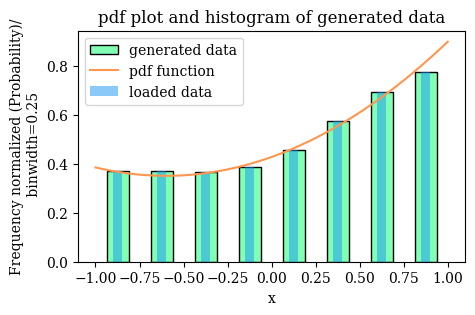

In [3]:
a_given=0.6
b_given=0.5

x_min=-1
x_max=1
N_samples=2000

integral=scipy.integrate.quad(lambda x: fct(x,a_given,b_given), x_min, x_max)[0]
print(f'Integral of function: {integral}')

x_sampled=sample_data_via_accept_reject(xmin=x_min, xmax=x_max, N_samples=N_samples, normalization_constant=integral)


fig,ax=plt.subplots(1)
ax.hist(x_sampled, bins=8, range=(x_min, x_max), density=True,color=my_cmap(0.5), edgecolor='black',rwidth=0.5,label="generated data")
x_points=np.linspace(x_min,x_max,1000)
ax.plot(x_points,sample_func(x_points,integral),color=my_cmap(0.8),label="pdf function")
ax.set_ylabel('Frequency normalized (Probability)/\n binwidth=0.25')
ax.set_xlabel('x')
ax.set_title('pdf plot and histogram of generated data')

#save to file"""
df = pd.DataFrame(x_sampled)
df.columns = ['x']
df.to_csv('sampled_normal_data_exc3.csv', index=False,sep=',')

#read from file"""
df_exc3 = pd.read_csv('sampled_normal_data_exc3.csv')

ax.hist(df_exc3['x'], bins=8, range=(x_min, x_max), density=True,color=my_cmap(0.2),rwidth=0.2,alpha=0.5, label="loaded data");
ax.legend()

In [4]:
df_exc3["x"][0]

np.float64(0.4639878836228102)

In [11]:
# fit
def fit_func_normalized(x, a,b) :
    #integral=scipy.integrate.quad(lambda x: fct(x,a,b), x_min, x_max)[0]
    integral= (2 * (1 + b / 3))
    y=fct(x,a,b)/integral
    return y


def neg_ln_likelihood(array,a,b):
    llh=0
    for x in array:
        llh=-np.log(fit_func_normalized(x, a, b))+llh
    return llh



mfit = Minuit(lambda a, b: neg_ln_likelihood(df_exc3["x"], a, b), a=starting_a, b=starting_b)
mfit.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1298                       │              Nfcn = 40               │
│ EDM = 1.01e-06 (Goal: 0.0002)    │            time = 0.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.57    │   0.07    │            │            │         │         │       │
│ 1 │ b    │   0.46    │   0.14    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────┐
│   │       a       b │
├───┼─────────────────┤
│ a │ 0.00521   0.005 │
│ b │   0.005  0.0202 │
└───┴─────────────────┘